# Bài 03 — Dịch máy hai chiều Anh ↔ Việt bằng Seq2Seq LSTM (không Attention)

Notebook xây dựng **hai mô hình Encoder–Decoder độc lập**:

1. English → Vietnamese (`en_to_vi`)
2. Vietnamese → English (`vi_to_en`)

Dữ liệu: [IWSLT'15 English–Vietnamese trên Kaggle](https://www.kaggle.com/datasets/tuannguyenvananh/iwslt15-englishvietnamesetrung).

Các yêu cầu được thực hiện đầy đủ: kiểm tra/làm sạch cặp câu, tokenizer riêng cho từng ngôn ngữ, vocabulary có `<SOS>`, `<EOS>`, `<PAD>`, `<UNK>`, padding động, Teacher Forcing, dịch câu chưa xuất hiện trong train và đánh giá **SacreBLEU**. Kiến trúc chỉ truyền hidden state/cell state từ Encoder sang Decoder, **không có Attention**.

## 1. Cài đặt thư viện

`kagglehub` dùng để tải dataset Kaggle khi môi trường chưa gắn sẵn dữ liệu. `sacrebleu` cung cấp cách tính BLEU có phiên bản và cấu hình rõ ràng.

In [2]:
!pip -q install -U kagglehub sacrebleu

## 2. Import

In [3]:
import html
import math
import os
import random
import re
import shutil
import tarfile
import time
import unicodedata
import urllib.request
from collections import Counter
from pathlib import Path
from typing import Iterable, Sequence

import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset

# Import PyTorch before NumPy/Pandas/Matplotlib to avoid a Windows DLL/OpenMP
# loading conflict in a few local Python distributions.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sacrebleu.metrics import BLEU
from tqdm.auto import tqdm

## 3. Cấu hình thí nghiệm

- Đặt `QUICK_RUN = True` để kiểm tra nhanh pipeline trên một phần dữ liệu.
- Giữ `QUICK_RUN = False` cho bài chạy chính thức với toàn bộ tập train sau làm sạch.
- Câu dài hơn `MAX_SENTENCE_TOKENS` bị loại vì mô hình không Attention phải nén cả câu vào một context vector cố định.

In [4]:
SEED = 42
DATASET_SLUG = "tuannguyenvananh/iwslt15-englishvietnamesetrung"

QUICK_RUN = False
QUICK_TRAIN_PAIRS = 10_000
QUICK_EVAL_PAIRS = 300

MAX_SENTENCE_TOKENS = 50
MAX_LENGTH_RATIO = 4.0
MIN_TOKEN_FREQUENCY = 2
MAX_VOCAB_SIZE = 20_000  # Bao gồm bốn special tokens.

BATCH_SIZE = 64
EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 2
DROPOUT = 0.30
LEARNING_RATE = 1e-3
EPOCHS = 2 if QUICK_RUN else 10
TEACHER_FORCING_RATIO = 0.50
GRADIENT_CLIP = 1.0
EARLY_STOPPING_PATIENCE = 3
MAX_DECODE_LENGTH = 60
NUM_WORKERS = 0

if Path("/kaggle/working").exists():
    BASE_DIR = Path("/kaggle/working/en_vi_seq2seq_no_attention")
elif Path("/content").exists():
    BASE_DIR = Path("/content/en_vi_seq2seq_no_attention")
else:
    BASE_DIR = Path.cwd() / "en_vi_seq2seq_no_attention"

DATA_DIR = BASE_DIR / "data"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"Artifacts: {BASE_DIR.resolve()}")
print(f"Quick run: {QUICK_RUN} | epochs: {EPOCHS}")

PyTorch: 2.13.0+cpu
Device: cpu
Artifacts: C:\content\en_vi_seq2seq_no_attention
Quick run: False | epochs: 10


## 4. Cố định seed

Cùng seed được dùng cho Python, NumPy, PyTorch và thứ tự shuffle của DataLoader.

In [5]:
def set_seed(seed: int = SEED) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed()

## 5. Tìm hoặc tải IWSLT'15

Thứ tự ưu tiên:

1. Dataset đã được gắn tại `/kaggle/input/...` hoặc đã có trong thư mục làm việc.
2. Tải đúng Kaggle dataset bằng `kagglehub`.
3. Nếu Kaggle yêu cầu đăng nhập/consent, tải mirror của đúng sáu file IWSLT'15 gốc (`train`, `tst2012`, `tst2013`).

Nhờ vậy notebook chạy được trên Kaggle, Colab và máy cá nhân. Loader luôn kiểm tra đủ sáu file trước khi tiếp tục.

In [6]:
REQUIRED_FILENAMES = (
    "train.en",
    "train.vi",
    "tst2012.en",
    "tst2012.vi",
    "tst2013.en",
    "tst2013.vi",
)

MIRROR_ARCHIVES = {
    "train-en-vi.tgz": (
        "https://raw.githubusercontent.com/stefan-it/nmt-en-vi/master/"
        "data/train-en-vi.tgz"
    ),
    "dev-2012-en-vi.tgz": (
        "https://raw.githubusercontent.com/stefan-it/nmt-en-vi/master/"
        "data/dev-2012-en-vi.tgz"
    ),
    "test-2013-en-vi.tgz": (
        "https://raw.githubusercontent.com/stefan-it/nmt-en-vi/master/"
        "data/test-2013-en-vi.tgz"
    ),
}


def locate_required_files(root: Path) -> dict[str, Path] | None:
    """Tìm đủ sáu file theo basename trong một thư mục và các thư mục con."""
    if not root.exists() or not root.is_dir():
        return None

    found: dict[str, Path] = {}
    for path in root.rglob("*"):
        if path.is_file() and path.name in REQUIRED_FILENAMES:
            found.setdefault(path.name, path)
    return found if all(name in found for name in REQUIRED_FILENAMES) else None


def download_iwslt_mirror(destination: Path) -> dict[str, Path]:
    """Tải và giải nén an toàn mirror của các file IWSLT'15 gốc."""
    destination.mkdir(parents=True, exist_ok=True)

    for archive_name, url in MIRROR_ARCHIVES.items():
        archive_path = destination / archive_name
        if not archive_path.exists():
            print(f"Downloading mirror: {archive_name}")
            temporary_path = archive_path.with_suffix(archive_path.suffix + ".part")
            urllib.request.urlretrieve(url, temporary_path)
            temporary_path.replace(archive_path)

        with tarfile.open(archive_path, mode="r:gz") as archive:
            for member in archive.getmembers():
                basename = Path(member.name).name
                if not member.isfile() or basename not in REQUIRED_FILENAMES:
                    continue
                output_path = destination / basename
                if output_path.exists():
                    continue
                source = archive.extractfile(member)
                if source is None:
                    raise RuntimeError(f"Cannot read {member.name} from {archive_path}")
                with source, output_path.open("wb") as target:
                    shutil.copyfileobj(source, target)

    files = locate_required_files(destination)
    if files is None:
        raise FileNotFoundError("Mirror download completed but required files are missing.")
    return files


def resolve_dataset_files() -> tuple[dict[str, Path], str]:
    dataset_folder_name = DATASET_SLUG.split("/")[-1]
    candidate_roots = [
        Path("/kaggle/input") / dataset_folder_name,
        Path("/kaggle/input"),
        DATA_DIR,
        Path.cwd() / "data",
    ]
    if Path.cwd() != Path(Path.cwd().anchor):
        candidate_roots.append(Path.cwd())

    for root in candidate_roots:
        files = locate_required_files(root)
        if files is not None:
            return files, f"local/Kaggle mount: {root}"

    try:
        import kagglehub

        downloaded_path = Path(kagglehub.dataset_download(DATASET_SLUG))
        files = locate_required_files(downloaded_path)
        if files is not None:
            return files, f"kagglehub: {downloaded_path}"
        print("Kaggle download succeeded, but the expected six files were not found.")
    except Exception as error:
        print(f"Kaggle download unavailable: {type(error).__name__}: {error}")

    files = download_iwslt_mirror(DATA_DIR)
    return files, f"IWSLT'15 mirror: {DATA_DIR}"


dataset_files, dataset_source = resolve_dataset_files()
print(f"Dataset source: {dataset_source}")

Dataset source: local/Kaggle mount: \content\en_vi_seq2seq_no_attention\data


## 6. Kiểm tra file và số dòng song song

Mỗi split phải có số dòng tiếng Anh bằng số dòng tiếng Việt. Không dùng `zip` để âm thầm bỏ dòng dư; nếu lệch, notebook dừng bằng lỗi rõ ràng.

In [7]:
def count_lines(path: Path) -> int:
    with path.open("r", encoding="utf-8", errors="strict") as file:
        return sum(1 for _ in file)


inventory_rows = []
for filename in REQUIRED_FILENAMES:
    path = dataset_files[filename]
    inventory_rows.append(
        {
            "file": filename,
            "size_MB": path.stat().st_size / (1024**2),
            "number_of_lines": count_lines(path),
            "path": str(path),
        }
    )

inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df.style.format({"size_MB": "{:.3f}"}))

for split_name in ("train", "tst2012", "tst2013"):
    en_count = int(
        inventory_df.loc[inventory_df["file"] == f"{split_name}.en", "number_of_lines"].iloc[0]
    )
    vi_count = int(
        inventory_df.loc[inventory_df["file"] == f"{split_name}.vi", "number_of_lines"].iloc[0]
    )
    if en_count != vi_count:
        raise ValueError(f"{split_name}: {en_count:,} EN lines != {vi_count:,} VI lines")
    print(f"{split_name:8s}: {en_count:,} aligned pairs")

,file,size_MB,number_of_lines,path
0,train.en,12.973,133317,\content\en_vi_seq2seq_no_attention\data\train.en
1,train.vi,17.237,133317,\content\en_vi_seq2seq_no_attention\data\train.vi
2,tst2012.en,0.134,1553,\content\en_vi_seq2seq_no_attention\data\tst2012.en
3,tst2012.vi,0.180,1553,\content\en_vi_seq2seq_no_attention\data\tst2012.vi
4,tst2013.en,0.126,1268,\content\en_vi_seq2seq_no_attention\data\tst2013.en
5,tst2013.vi,0.175,1268,\content\en_vi_seq2seq_no_attention\data\tst2013.vi


train   : 133,317 aligned pairs
tst2012 : 1,553 aligned pairs
tst2013 : 1,268 aligned pairs


In [8]:
def read_utf8_lines(path: Path) -> list[str]:
    return path.read_text(encoding="utf-8", errors="strict").splitlines()


raw_lines: dict[str, dict[str, list[str]]] = {}
for split_name in ("train", "tst2012", "tst2013"):
    raw_lines[split_name] = {
        "en": read_utf8_lines(dataset_files[f"{split_name}.en"]),
        "vi": read_utf8_lines(dataset_files[f"{split_name}.vi"]),
    }

raw_preview = pd.DataFrame(
    {
        "English": raw_lines["train"]["en"][:5],
        "Vietnamese": raw_lines["train"]["vi"][:5],
    }
)
display(raw_preview)

,English,Vietnamese
0,Rachel Pike : The science behind a climate hea...,Khoa học đằng sau một tiêu đề về khí hậu
1,"In 4 minutes , atmospheric chemist Rachel Pike...","Trong 4 phút , chuyên gia hoá học khí quyển Ra..."
2,I &apos;d like to talk to you today about the ...,Tôi muốn cho các bạn biết về sự to lớn của nhữ...
3,Headlines that look like this when they have t...,Có những dòng trông như thế này khi bàn về biế...
4,They are both two branches of the same field o...,Cả hai đều là một nhánh của cùng một lĩnh vực ...


## 7. Chuẩn hóa và tokenize riêng cho tiếng Anh/tiếng Việt

Hai tokenizer là hai hàm độc lập:

- English tokenizer giữ contraction như `don't` thành một token.
- Vietnamese tokenizer hỗ trợ ký tự Unicode có dấu và token ghép bằng `_`.

IWSLT'15 đã có khoảng trắng quanh phần lớn dấu câu. Regex vẫn được áp dụng lại để cách xử lý câu nhập mới nhất quán với dữ liệu huấn luyện. Không xóa dấu tiếng Việt.

In [9]:
WHITESPACE_RE = re.compile(r"\s+")
HTML_TAG_RE = re.compile(r"<[^>]+>")
CONTROL_CHARACTER_RE = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]")
ENGLISH_TOKEN_RE = re.compile(r"\w+(?:['’]\w+)?|[^\w\s]", flags=re.UNICODE)
VIETNAMESE_TOKEN_RE = re.compile(r"\w+(?:[_'’]\w+)*|[^\w\s]", flags=re.UNICODE)


def normalize_text(text: str, lowercase: bool = True) -> str:
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("##AT##-##AT##", "-").replace("\u00a0", " ")
    text = HTML_TAG_RE.sub(" ", text)
    text = CONTROL_CHARACTER_RE.sub(" ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text.lower() if lowercase else text


def tokenize_english(text: str) -> list[str]:
    """Tokenizer riêng cho tiếng Anh."""
    # IWSLT/Moses có thể lưu "I &apos;d"; sau html.unescape nó thành
    # "I 'd". Ghép lại để câu trong corpus và câu người dùng được xử lý giống nhau.
    text = re.sub(
        r"\b(\w+)\s+(['’](?:s|re|ve|ll|d|m|t))\b",
        r"\1\2",
        text,
        flags=re.IGNORECASE,
    )
    return ENGLISH_TOKEN_RE.findall(text)


def tokenize_vietnamese(text: str) -> list[str]:
    """Tokenizer riêng cho tiếng Việt; giữ nguyên dấu và dấu gạch dưới."""
    return VIETNAMESE_TOKEN_RE.findall(text)


TOKENIZERS = {"en": tokenize_english, "vi": tokenize_vietnamese}

tokenizer_demo = pd.DataFrame(
    [
        {
            "language": "en",
            "sentence": "I don't remove punctuation, and I'm ready!",
            "tokens": tokenize_english(normalize_text("I don't remove punctuation, and I'm ready!")),
        },
        {
            "language": "vi",
            "sentence": "Tôi đang học xử_lý ngôn ngữ tự nhiên!",
            "tokens": tokenize_vietnamese(normalize_text("Tôi đang học xử_lý ngôn ngữ tự nhiên!")),
        },
    ]
)
display(tokenizer_demo)

,language,sentence,tokens
0,en,"I don't remove punctuation, and I'm ready!","[i, don't, remove, punctuation, ,, and, i'm, r..."
1,vi,Tôi đang học xử_lý ngôn ngữ tự nhiên!,"[tôi, đang, học, xử_lý, ngôn, ngữ, tự, nhiên, !]"


## 8. Làm sạch từng cặp câu

Một cặp bị loại nếu rỗng, chứa ký tự thay thế Unicode, quá dài, chênh lệch độ dài bất thường hoặc trùng hoàn toàn trong cùng split. Cell trả về thống kê cụ thể thay vì làm sạch âm thầm.

In [10]:
def clean_parallel_split(
    split_name: str,
    english_lines: Sequence[str],
    vietnamese_lines: Sequence[str],
) -> tuple[pd.DataFrame, Counter]:
    if len(english_lines) != len(vietnamese_lines):
        raise ValueError(
            f"{split_name}: {len(english_lines):,} English lines != "
            f"{len(vietnamese_lines):,} Vietnamese lines"
        )

    statistics = Counter(raw_pairs=len(english_lines))
    records = []
    seen_pairs: set[tuple[str, str]] = set()

    for line_number, (english_raw, vietnamese_raw) in enumerate(
        zip(english_lines, vietnamese_lines), start=1
    ):
        english = normalize_text(english_raw)
        vietnamese = normalize_text(vietnamese_raw)

        if not english or not vietnamese:
            statistics["removed_empty"] += 1
            continue
        if "\ufffd" in english or "\ufffd" in vietnamese:
            statistics["removed_unicode_replacement"] += 1
            continue

        english_tokens = tokenize_english(english)
        vietnamese_tokens = tokenize_vietnamese(vietnamese)
        if not english_tokens or not vietnamese_tokens:
            statistics["removed_no_tokens"] += 1
            continue
        if max(len(english_tokens), len(vietnamese_tokens)) > MAX_SENTENCE_TOKENS:
            statistics["removed_too_long"] += 1
            continue

        length_ratio = max(len(english_tokens), len(vietnamese_tokens)) / min(
            len(english_tokens), len(vietnamese_tokens)
        )
        if length_ratio > MAX_LENGTH_RATIO:
            statistics["removed_length_ratio"] += 1
            continue

        pair_key = (" ".join(english_tokens), " ".join(vietnamese_tokens))
        if pair_key in seen_pairs:
            statistics["removed_duplicate"] += 1
            continue
        seen_pairs.add(pair_key)

        if english == vietnamese:
            statistics["kept_identical_text"] += 1

        records.append(
            {
                "line_number": line_number,
                "en": english,
                "vi": vietnamese,
                "en_tokens": english_tokens,
                "vi_tokens": vietnamese_tokens,
                "en_length": len(english_tokens),
                "vi_length": len(vietnamese_tokens),
            }
        )
        statistics["kept"] += 1

    frame = pd.DataFrame.from_records(records)
    if frame.empty:
        raise ValueError(f"No valid sentence pairs remain in {split_name}.")
    return frame, statistics


split_mapping = {"train": "train", "validation": "tst2012", "test": "tst2013"}
clean_frames: dict[str, pd.DataFrame] = {}
cleaning_statistics = []

for logical_split, file_split in split_mapping.items():
    frame, statistics = clean_parallel_split(
        logical_split,
        raw_lines[file_split]["en"],
        raw_lines[file_split]["vi"],
    )
    clean_frames[logical_split] = frame
    cleaning_statistics.append({"split": logical_split, **dict(statistics)})

cleaning_report_df = pd.DataFrame(cleaning_statistics).fillna(0)
numeric_columns = cleaning_report_df.columns.drop("split")
cleaning_report_df[numeric_columns] = cleaning_report_df[numeric_columns].astype(int)
display(cleaning_report_df)

,split,raw_pairs,kept,removed_too_long,kept_identical_text,removed_empty,removed_duplicate,removed_length_ratio
0,train,133317,120931,11204,117,151,1020,11
1,validation,1553,1489,62,2,0,2,0
2,test,1268,1146,115,1,0,7,0


## 9. Loại rò rỉ giữa train/validation/test

Các split chính thức vẫn được giữ nguyên vai trò. Nếu một cặp trùng xuất hiện ở split sau, cặp đó bị loại khỏi split sau. Vocabulary chỉ được tạo từ `train`.

In [11]:
def frame_pair_keys(frame: pd.DataFrame) -> list[tuple[str, str]]:
    return list(zip(frame["en"], frame["vi"]))


def remove_overlap(
    frame: pd.DataFrame,
    forbidden_pairs: set[tuple[str, str]],
    split_name: str,
) -> tuple[pd.DataFrame, int]:
    keys = frame_pair_keys(frame)
    keep_mask = [key not in forbidden_pairs for key in keys]
    removed = len(keep_mask) - sum(keep_mask)
    cleaned = frame.loc[keep_mask].reset_index(drop=True)
    print(f"{split_name}: removed {removed:,} pairs overlapping earlier splits")
    return cleaned, removed


train_full_df = clean_frames["train"].reset_index(drop=True)
train_pair_set = set(frame_pair_keys(train_full_df))

validation_full_df, _ = remove_overlap(
    clean_frames["validation"], train_pair_set, "validation"
)
validation_pair_set = set(frame_pair_keys(validation_full_df))

test_full_df, _ = remove_overlap(
    clean_frames["test"], train_pair_set | validation_pair_set, "test"
)

if QUICK_RUN:
    train_df = (
        train_full_df.sample(
            n=min(QUICK_TRAIN_PAIRS, len(train_full_df)), random_state=SEED
        )
        .sort_values("line_number")
        .reset_index(drop=True)
    )
    validation_df = validation_full_df.head(QUICK_EVAL_PAIRS).reset_index(drop=True)
    test_df = test_full_df.head(QUICK_EVAL_PAIRS).reset_index(drop=True)
else:
    train_df = train_full_df.copy()
    validation_df = validation_full_df.copy()
    test_df = test_full_df.copy()

assert set(frame_pair_keys(train_df)).isdisjoint(frame_pair_keys(validation_df))
assert set(frame_pair_keys(train_df)).isdisjoint(frame_pair_keys(test_df))
assert set(frame_pair_keys(validation_df)).isdisjoint(frame_pair_keys(test_df))

split_frames = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}

print(
    f"Used pairs — train: {len(train_df):,}, validation: {len(validation_df):,}, "
    f"test: {len(test_df):,}"
)

validation: removed 12 pairs overlapping earlier splits
test: removed 12 pairs overlapping earlier splits
Used pairs — train: 120,931, validation: 1,477, test: 1,134


## 10. Thống kê sau làm sạch

,split,pairs,mean_en_length,p95_en_length,max_en_length,mean_vi_length,p95_vi_length,max_vi_length
0,train,120931,17.18,35.0,50,21.09,43.0,50
1,validation,1477,16.60,33.0,50,20.50,42.0,50
2,test,1134,18.07,35.0,47,22.91,45.0,50


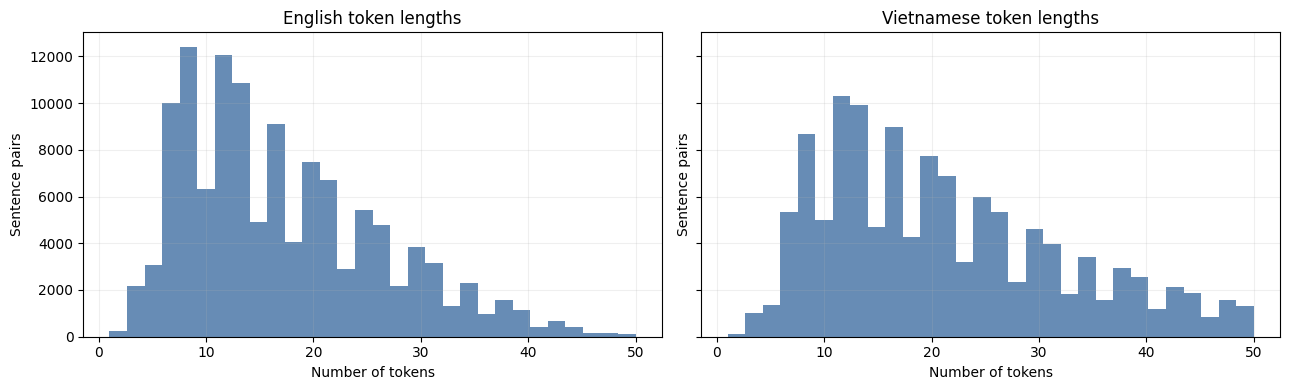

In [12]:
def summarize_split(name: str, frame: pd.DataFrame) -> dict[str, float | int | str]:
    return {
        "split": name,
        "pairs": len(frame),
        "mean_en_length": frame["en_length"].mean(),
        "p95_en_length": frame["en_length"].quantile(0.95),
        "max_en_length": frame["en_length"].max(),
        "mean_vi_length": frame["vi_length"].mean(),
        "p95_vi_length": frame["vi_length"].quantile(0.95),
        "max_vi_length": frame["vi_length"].max(),
    }


split_summary_df = pd.DataFrame(
    [summarize_split(name, frame) for name, frame in split_frames.items()]
)
display(
    split_summary_df.style.format(
        {
            "mean_en_length": "{:.2f}",
            "p95_en_length": "{:.1f}",
            "mean_vi_length": "{:.2f}",
            "p95_vi_length": "{:.1f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, column, title in (
    (axes[0], "en_length", "English token lengths"),
    (axes[1], "vi_length", "Vietnamese token lengths"),
):
    axis.hist(train_df[column], bins=30, alpha=0.85, color="#4C78A8")
    axis.set_title(title)
    axis.set_xlabel("Number of tokens")
    axis.set_ylabel("Sentence pairs")
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 11. Tạo vocabulary từ tập train

Thứ tự ID của special tokens được cố định:

- `<PAD>` = 0
- `<SOS>` = 1
- `<EOS>` = 2
- `<UNK>` = 3

Token validation/test không có trong train được ánh xạ sang `<UNK>` để tránh data leakage.

In [13]:
PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"
SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]


class Vocabulary:
    def __init__(
        self,
        token_sequences: Iterable[Sequence[str]],
        min_frequency: int = 1,
        max_size: int | None = None,
    ) -> None:
        self.counter = Counter(token for sequence in token_sequences for token in sequence)
        candidates = [
            (token, frequency)
            for token, frequency in self.counter.items()
            if frequency >= min_frequency and token not in SPECIAL_TOKENS
        ]
        candidates.sort(key=lambda item: (-item[1], item[0]))

        if max_size is not None:
            candidates = candidates[: max(0, max_size - len(SPECIAL_TOKENS))]

        self.id_to_token = SPECIAL_TOKENS + [token for token, _ in candidates]
        self.token_to_id = {
            token: token_id for token_id, token in enumerate(self.id_to_token)
        }

        self.pad_id = self.token_to_id[PAD_TOKEN]
        self.sos_id = self.token_to_id[SOS_TOKEN]
        self.eos_id = self.token_to_id[EOS_TOKEN]
        self.unk_id = self.token_to_id[UNK_TOKEN]

    def __len__(self) -> int:
        return len(self.id_to_token)

    def encode(
        self, tokens: Sequence[str], add_boundary_tokens: bool = True
    ) -> list[int]:
        token_ids = [self.token_to_id.get(token, self.unk_id) for token in tokens]
        if add_boundary_tokens:
            token_ids = [self.sos_id, *token_ids, self.eos_id]
        return token_ids

    def decode(
        self,
        token_ids: Sequence[int],
        stop_at_eos: bool = True,
        skip_special_tokens: bool = True,
    ) -> list[str]:
        tokens = []
        for token_id in token_ids:
            token = self.id_to_token[int(token_id)]
            if stop_at_eos and token == EOS_TOKEN:
                break
            # Giữ <UNK> trong output: đây là một dự đoán có ý nghĩa và phải bị
            # BLEU phạt. Chỉ bỏ padding/boundary tokens.
            if skip_special_tokens and token in {PAD_TOKEN, SOS_TOKEN, EOS_TOKEN}:
                continue
            tokens.append(token)
        return tokens


english_vocab = Vocabulary(
    train_df["en_tokens"],
    min_frequency=MIN_TOKEN_FREQUENCY,
    max_size=MAX_VOCAB_SIZE,
)
vietnamese_vocab = Vocabulary(
    train_df["vi_tokens"],
    min_frequency=MIN_TOKEN_FREQUENCY,
    max_size=MAX_VOCAB_SIZE,
)
VOCABS = {"en": english_vocab, "vi": vietnamese_vocab}

for language, vocabulary in VOCABS.items():
    assert vocabulary.id_to_token[:4] == SPECIAL_TOKENS
    print(
        f"{language.upper()} vocabulary: {len(vocabulary):,} / "
        f"{len(vocabulary.counter):,} observed unique tokens"
    )
    print("  12 most frequent:", vocabulary.counter.most_common(12))

EN vocabulary: 20,000 / 39,107 observed unique tokens
  12 most frequent: [('.', 121434), (',', 113688), ('the', 84076), ('and', 59226), ('to', 50118), ('of', 45480), ('a', 43041), ('that', 32772), ('in', 31339), ('i', 29411), ('is', 27957), ('you', 26138)]
VI vocabulary: 10,171 / 17,702 observed unique tokens
  12 most frequent: [('.', 109961), (',', 91977), ('tôi', 52806), ('và', 49225), ('là', 47588), ('có', 39808), ('một', 39339), ('chúng', 35475), ('những', 28882), ('của', 27210), ('không', 26510), ('bạn', 24063)]


In [14]:
def unknown_rate(frame: pd.DataFrame, language: str, vocabulary: Vocabulary) -> float:
    token_column = f"{language}_tokens"
    total = 0
    unknown = 0
    for tokens in frame[token_column]:
        total += len(tokens)
        unknown += sum(token not in vocabulary.token_to_id for token in tokens)
    return unknown / max(total, 1)


coverage_rows = []
for split_name, frame in split_frames.items():
    coverage_rows.append(
        {
            "split": split_name,
            "English_UNK_rate": unknown_rate(frame, "en", english_vocab),
            "Vietnamese_UNK_rate": unknown_rate(frame, "vi", vietnamese_vocab),
        }
    )
display(pd.DataFrame(coverage_rows).style.format({"English_UNK_rate": "{:.2%}", "Vietnamese_UNK_rate": "{:.2%}"}))

,split,English_UNK_rate,Vietnamese_UNK_rate
0,train,1.15%,0.30%
1,validation,1.81%,0.60%
2,test,2.22%,0.59%


## 12. Dataset, padding động và DataLoader

Mỗi câu được thêm `<SOS>` và `<EOS>`. `pad_sequence` chỉ pad đến câu dài nhất trong batch, bằng ID của `<PAD>`. Source lengths được giữ lại để Encoder dùng packed sequence và bỏ qua padding.

In [15]:
DIRECTION_SPECS = {
    "en_to_vi": {
        "label": "English → Vietnamese",
        "source_language": "en",
        "target_language": "vi",
        "source_column": "en_tokens",
        "target_column": "vi_tokens",
    },
    "vi_to_en": {
        "label": "Vietnamese → English",
        "source_language": "vi",
        "target_language": "en",
        "source_column": "vi_tokens",
        "target_column": "en_tokens",
    },
}


class ParallelTranslationDataset(Dataset):
    def __init__(
        self,
        frame: pd.DataFrame,
        source_column: str,
        target_column: str,
        source_vocab: Vocabulary,
        target_vocab: Vocabulary,
    ) -> None:
        self.frame = frame.reset_index(drop=True)
        self.source_column = source_column
        self.target_column = target_column
        self.source_vocab = source_vocab
        self.target_vocab = target_vocab

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        row = self.frame.iloc[index]
        source_ids = self.source_vocab.encode(row[self.source_column])
        target_ids = self.target_vocab.encode(row[self.target_column])
        return (
            torch.tensor(source_ids, dtype=torch.long),
            torch.tensor(target_ids, dtype=torch.long),
        )


def make_collate_fn(source_pad_id: int, target_pad_id: int):
    def collate_batch(batch: list[tuple[torch.Tensor, torch.Tensor]]) -> dict[str, torch.Tensor]:
        source_sequences, target_sequences = zip(*batch)
        source_lengths = torch.tensor(
            [len(sequence) for sequence in source_sequences], dtype=torch.long
        )
        source_batch = pad_sequence(
            source_sequences, batch_first=True, padding_value=source_pad_id
        )
        target_batch = pad_sequence(
            target_sequences, batch_first=True, padding_value=target_pad_id
        )
        return {
            "source": source_batch,
            "source_lengths": source_lengths,
            "target": target_batch,
        }

    return collate_batch


def create_direction_data(direction: str) -> dict:
    spec = DIRECTION_SPECS[direction]
    source_vocab = VOCABS[spec["source_language"]]
    target_vocab = VOCABS[spec["target_language"]]
    collate_fn = make_collate_fn(source_vocab.pad_id, target_vocab.pad_id)

    datasets = {
        split_name: ParallelTranslationDataset(
            frame,
            spec["source_column"],
            spec["target_column"],
            source_vocab,
            target_vocab,
        )
        for split_name, frame in split_frames.items()
    }

    generator = torch.Generator().manual_seed(SEED)
    common = {
        "batch_size": BATCH_SIZE,
        "collate_fn": collate_fn,
        "num_workers": NUM_WORKERS,
        "pin_memory": DEVICE.type == "cuda",
        "persistent_workers": NUM_WORKERS > 0,
    }
    loaders = {
        "train": DataLoader(
            datasets["train"], shuffle=True, generator=generator, **common
        ),
        "validation": DataLoader(datasets["validation"], shuffle=False, **common),
        "test": DataLoader(datasets["test"], shuffle=False, **common),
    }
    return {
        "spec": spec,
        "source_vocab": source_vocab,
        "target_vocab": target_vocab,
        "datasets": datasets,
        "loaders": loaders,
    }


direction_data = {
    direction: create_direction_data(direction) for direction in DIRECTION_SPECS
}

## 13. Kiểm tra một batch đã padding

In [16]:
for direction, data_bundle in direction_data.items():
    batch = next(iter(data_bundle["loaders"]["train"]))
    source_vocab = data_bundle["source_vocab"]
    target_vocab = data_bundle["target_vocab"]
    print(f"\n{data_bundle['spec']['label']}")
    print("source shape:", tuple(batch["source"].shape))
    print("target shape:", tuple(batch["target"].shape))
    print("source lengths:", batch["source_lengths"][:8].tolist())
    print("source PAD id:", source_vocab.pad_id, "| target PAD id:", target_vocab.pad_id)
    print("decoded source[0]:", source_vocab.decode(batch["source"][0].tolist())[:30])
    print("decoded target[0]:", target_vocab.decode(batch["target"][0].tolist())[:30])


English → Vietnamese
source shape: (64, 38)
target shape: (64, 52)
source lengths: [12, 38, 20, 13, 26, 9, 6, 16]
source PAD id: 0 | target PAD id: 0
decoded source[0]: ['and', 'so', 'we', 'need', 'a', 'post', '-', 'conflict', 'compact', '.']
decoded target[0]: ['vậy', 'chúng', 'ta', 'cần', 'thoả', 'thuận', 'sau', 'chiến', 'tranh', '.']

Vietnamese → English
source shape: (64, 52)
target shape: (64, 38)
source lengths: [12, 39, 24, 16, 34, 9, 9, 25]
source PAD id: 0 | target PAD id: 0
decoded source[0]: ['vậy', 'chúng', 'ta', 'cần', 'thoả', 'thuận', 'sau', 'chiến', 'tranh', '.']
decoded target[0]: ['and', 'so', 'we', 'need', 'a', 'post', '-', 'conflict', 'compact', '.']


## 14. Encoder–Decoder LSTM không Attention

Encoder đọc toàn bộ source và trả về `(hidden, cell)`. Decoder chỉ nhận hai tensor này làm context ban đầu; output theo từng thời điểm của Encoder không được giữ hoặc truy vấn. Đây chính là Seq2Seq cổ điển **không Attention**.

In [17]:
class EncoderLSTM(nn.Module):
    def __init__(
        self,
        vocabulary_size: int,
        embedding_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        pad_id: int,
    ) -> None:
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding(
            vocabulary_size, embedding_dim, padding_idx=pad_id
        )
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )

    def forward(
        self, source: torch.Tensor, source_lengths: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        embedded = self.dropout(self.embedding(source))
        packed = pack_padded_sequence(
            embedded,
            source_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, cell) = self.lstm(packed)
        return hidden, cell


class DecoderLSTM(nn.Module):
    def __init__(
        self,
        vocabulary_size: int,
        embedding_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        pad_id: int,
    ) -> None:
        super().__init__()
        self.output_dim = vocabulary_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding(
            vocabulary_size, embedding_dim, padding_idx=pad_id
        )
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.output_projection = nn.Linear(hidden_dim, vocabulary_size)

    def forward(
        self,
        input_token: torch.Tensor,
        hidden: torch.Tensor,
        cell: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        logits = self.output_projection(output.squeeze(1))
        return logits, hidden, cell


class Seq2SeqLSTM(nn.Module):
    def __init__(self, encoder: EncoderLSTM, decoder: DecoderLSTM) -> None:
        super().__init__()
        if encoder.hidden_dim != decoder.hidden_dim:
            raise ValueError("Encoder and decoder hidden dimensions must match.")
        if encoder.num_layers != decoder.num_layers:
            raise ValueError("Encoder and decoder layer counts must match.")
        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        source: torch.Tensor,
        source_lengths: torch.Tensor,
        target: torch.Tensor,
        teacher_forcing_ratio: float = 0.5,
    ) -> torch.Tensor:
        batch_size, target_length = target.shape
        outputs = torch.zeros(
            batch_size,
            target_length,
            self.decoder.output_dim,
            device=source.device,
        )

        hidden, cell = self.encoder(source, source_lengths)
        input_token = target[:, 0]  # <SOS>

        for time_step in range(1, target_length):
            logits, hidden, cell = self.decoder(input_token, hidden, cell)
            outputs[:, time_step] = logits
            greedy_token = logits.argmax(dim=1)
            use_teacher = random.random() < teacher_forcing_ratio
            input_token = target[:, time_step] if use_teacher else greedy_token

        return outputs


def initialize_model(model: nn.Module) -> None:
    for parameter in model.parameters():
        if parameter.dim() > 1:
            nn.init.xavier_uniform_(parameter)
        else:
            nn.init.zeros_(parameter)

    with torch.no_grad():
        model.encoder.embedding.weight[model.encoder.embedding.padding_idx].zero_()
        model.decoder.embedding.weight[model.decoder.embedding.padding_idx].zero_()


def build_model(direction: str) -> Seq2SeqLSTM:
    data_bundle = direction_data[direction]
    source_vocab = data_bundle["source_vocab"]
    target_vocab = data_bundle["target_vocab"]
    encoder = EncoderLSTM(
        len(source_vocab),
        EMBEDDING_DIM,
        HIDDEN_DIM,
        NUM_LAYERS,
        DROPOUT,
        source_vocab.pad_id,
    )
    decoder = DecoderLSTM(
        len(target_vocab),
        EMBEDDING_DIM,
        HIDDEN_DIM,
        NUM_LAYERS,
        DROPOUT,
        target_vocab.pad_id,
    )
    model = Seq2SeqLSTM(encoder, decoder)
    initialize_model(model)
    return model


for direction, spec in DIRECTION_SPECS.items():
    temporary_model = build_model(direction)
    number_of_parameters = sum(p.numel() for p in temporary_model.parameters())
    print(f"{spec['label']}: {number_of_parameters:,} trainable parameters")
    del temporary_model

English → Vietnamese: 20,297,915 trainable parameters
Vietnamese → English: 25,340,192 trainable parameters


## 15. Teacher Forcing, loss và vòng lặp huấn luyện

Ở train, với xác suất `TEACHER_FORCING_RATIO`, token đúng tại bước hiện tại được đưa vào Decoder ở bước tiếp theo. Ở validation, ratio bằng 0 để phản ánh suy luận tự hồi quy. Loss và token accuracy đều bỏ qua `<PAD>`.

In [18]:
def run_epoch(
    model: Seq2SeqLSTM,
    dataloader: DataLoader,
    criterion: nn.Module,
    target_pad_id: int,
    optimizer: torch.optim.Optimizer | None = None,
    teacher_forcing_ratio: float = 0.0,
) -> dict[str, float]:
    is_training = optimizer is not None
    model.train(is_training)

    total_weighted_loss = 0.0
    total_tokens = 0
    total_correct = 0

    progress = tqdm(
        dataloader,
        desc="train" if is_training else "validation",
        leave=False,
    )
    for batch in progress:
        source = batch["source"].to(DEVICE, non_blocking=True)
        source_lengths = batch["source_lengths"]
        target = batch["target"].to(DEVICE, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(
                source,
                source_lengths,
                target,
                teacher_forcing_ratio=teacher_forcing_ratio,
            )
            prediction_logits = logits[:, 1:].reshape(-1, logits.size(-1))
            target_tokens = target[:, 1:].reshape(-1)
            loss = criterion(prediction_logits, target_tokens)

            if is_training:
                loss.backward()
                clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
                optimizer.step()

        non_padding_mask = target_tokens.ne(target_pad_id)
        real_token_count = int(non_padding_mask.sum().item())
        predictions = prediction_logits.argmax(dim=1)
        correct = int(
            predictions.eq(target_tokens).logical_and(non_padding_mask).sum().item()
        )

        total_weighted_loss += loss.item() * real_token_count
        total_tokens += real_token_count
        total_correct += correct
        progress.set_postfix(loss=f"{loss.item():.4f}")

    mean_loss = total_weighted_loss / max(total_tokens, 1)
    return {
        "loss": mean_loss,
        "perplexity": math.exp(min(mean_loss, 20.0)),
        "token_accuracy": total_correct / max(total_tokens, 1),
    }


def load_local_checkpoint(path: Path) -> dict:
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:  # Tương thích các bản PyTorch cũ.
        return torch.load(path, map_location="cpu")


def train_direction(direction: str) -> tuple[Seq2SeqLSTM, dict[str, list[float]], Path]:
    set_seed(SEED)
    data_bundle = direction_data[direction]
    target_vocab = data_bundle["target_vocab"]
    model = build_model(direction).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(ignore_index=target_vocab.pad_id)

    history = {
        "train_loss": [],
        "validation_loss": [],
        "train_token_accuracy": [],
        "validation_token_accuracy": [],
    }
    checkpoint_path = CHECKPOINT_DIR / f"best_{direction}_seq2seq_lstm.pt"
    best_validation_loss = float("inf")
    epochs_without_improvement = 0

    print("\n" + "=" * 90)
    print(f"Training {data_bundle['spec']['label']}")
    print("=" * 90)

    for epoch in range(1, EPOCHS + 1):
        start_time = time.perf_counter()
        train_metrics = run_epoch(
            model,
            data_bundle["loaders"]["train"],
            criterion,
            target_vocab.pad_id,
            optimizer=optimizer,
            teacher_forcing_ratio=TEACHER_FORCING_RATIO,
        )
        validation_metrics = run_epoch(
            model,
            data_bundle["loaders"]["validation"],
            criterion,
            target_vocab.pad_id,
            optimizer=None,
            teacher_forcing_ratio=0.0,
        )

        history["train_loss"].append(train_metrics["loss"])
        history["validation_loss"].append(validation_metrics["loss"])
        history["train_token_accuracy"].append(train_metrics["token_accuracy"])
        history["validation_token_accuracy"].append(
            validation_metrics["token_accuracy"]
        )

        elapsed = time.perf_counter() - start_time
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | {elapsed:6.1f}s | "
            f"train loss {train_metrics['loss']:.4f}, ppl {train_metrics['perplexity']:.2f}, "
            f"acc {train_metrics['token_accuracy']:.3f} | "
            f"val loss {validation_metrics['loss']:.4f}, "
            f"ppl {validation_metrics['perplexity']:.2f}, "
            f"acc {validation_metrics['token_accuracy']:.3f}"
        )

        if validation_metrics["loss"] < best_validation_loss:
            best_validation_loss = validation_metrics["loss"]
            epochs_without_improvement = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "direction": direction,
                    "best_validation_loss": best_validation_loss,
                    "source_vocabulary": data_bundle["source_vocab"].id_to_token,
                    "target_vocabulary": target_vocab.id_to_token,
                    "model_config": {
                        "embedding_dim": EMBEDDING_DIM,
                        "hidden_dim": HIDDEN_DIM,
                        "num_layers": NUM_LAYERS,
                        "dropout": DROPOUT,
                    },
                },
                checkpoint_path,
            )
            print(f"  Saved best checkpoint: {checkpoint_path}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print("  Early stopping.")
                break

    checkpoint = load_local_checkpoint(checkpoint_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return model, history, checkpoint_path

## 16. Huấn luyện hai chiều

Cell này lần lượt huấn luyện hai mô hình. Mô hình tốt nhất theo validation loss được nạp lại; mô hình thứ nhất được chuyển về CPU trước khi huấn luyện mô hình thứ hai để tiết kiệm VRAM.

In [19]:
trained_models: dict[str, Seq2SeqLSTM] = {}
training_histories: dict[str, dict[str, list[float]]] = {}
checkpoint_paths: dict[str, Path] = {}

for direction in DIRECTION_SPECS:
    model, history, checkpoint_path = train_direction(direction)
    trained_models[direction] = model
    training_histories[direction] = history
    checkpoint_paths[direction] = checkpoint_path


Training English → Vietnamese


train:   0%|          | 0/1890 [00:00<?, ?it/s]

validation:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 01/10 | 9305.4s | train loss 5.6964, ppl 297.78, acc 0.122 | val loss 5.6891, ppl 295.63, acc 0.108
  Saved best checkpoint: \content\en_vi_seq2seq_no_attention\checkpoints\best_en_to_vi_seq2seq_lstm.pt


train:   0%|          | 0/1890 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 17. Đồ thị train/validation loss

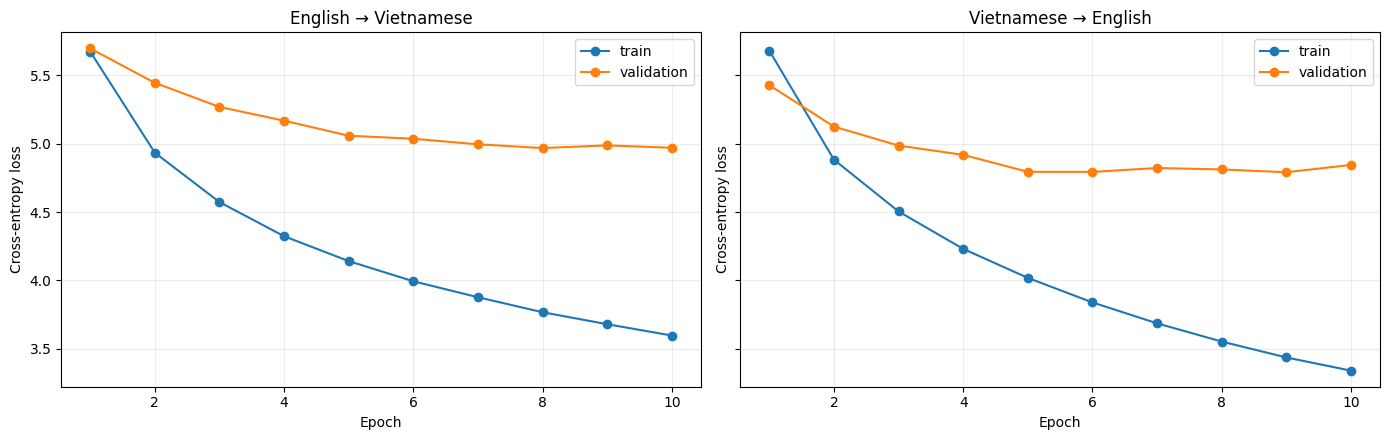

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for axis, direction in zip(axes, DIRECTION_SPECS):
    history = training_histories[direction]
    epochs = range(1, len(history["train_loss"]) + 1)
    axis.plot(epochs, history["train_loss"], marker="o", label="train")
    axis.plot(epochs, history["validation_loss"], marker="o", label="validation")
    axis.set_title(DIRECTION_SPECS[direction]["label"])
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Cross-entropy loss")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

## 18. Greedy decoding theo batch

Khi inference không có Teacher Forcing. Decoder bắt đầu bằng `<SOS>`, lấy token có xác suất lớn nhất ở mỗi bước và dừng tại `<EOS>` hoặc `MAX_DECODE_LENGTH`.

In [20]:
@torch.inference_mode()
def greedy_decode_batch(
    model: Seq2SeqLSTM,
    source: torch.Tensor,
    source_lengths: torch.Tensor,
    target_vocab: Vocabulary,
    max_length: int = MAX_DECODE_LENGTH,
) -> torch.Tensor:
    model.eval()
    hidden, cell = model.encoder(source, source_lengths)
    batch_size = source.size(0)
    input_token = torch.full(
        (batch_size,), target_vocab.sos_id, dtype=torch.long, device=source.device
    )
    finished = torch.zeros(batch_size, dtype=torch.bool, device=source.device)
    generated_steps = []

    for _ in range(max_length):
        logits, hidden, cell = model.decoder(input_token, hidden, cell)
        next_token = logits.argmax(dim=1)
        next_token = torch.where(
            finished,
            torch.full_like(next_token, target_vocab.eos_id),
            next_token,
        )
        generated_steps.append(next_token)
        finished |= next_token.eq(target_vocab.eos_id)
        input_token = next_token
        if bool(finished.all()):
            break

    return torch.stack(generated_steps, dim=1)


def metric_text(token_ids: Sequence[int], vocabulary: Vocabulary) -> str:
    return " ".join(vocabulary.decode(token_ids))


@torch.inference_mode()
def evaluate_sacrebleu(
    direction: str,
) -> tuple[dict[str, float | str], list[str], list[str]]:
    data_bundle = direction_data[direction]
    target_vocab = data_bundle["target_vocab"]
    model = trained_models[direction].to(DEVICE)
    hypotheses: list[str] = []
    # Reference lấy trực tiếp từ token gốc của test, không decode qua vocabulary.
    # Nhờ vậy từ OOV trong reference không bị biến thành <UNK>.
    references = [
        " ".join(tokens)
        for tokens in data_bundle["datasets"]["test"].frame[
            data_bundle["spec"]["target_column"]
        ]
    ]

    progress = tqdm(
        data_bundle["loaders"]["test"],
        desc=f"BLEU {data_bundle['spec']['label']}",
        leave=False,
    )
    for batch in progress:
        source = batch["source"].to(DEVICE, non_blocking=True)
        generated = greedy_decode_batch(
            model,
            source,
            batch["source_lengths"],
            target_vocab,
        ).cpu()

        hypotheses.extend(
            metric_text(row.tolist(), target_vocab) for row in generated
        )
    if len(hypotheses) != len(references):
        raise RuntimeError(
            f"{direction}: {len(hypotheses)} hypotheses != {len(references)} references"
        )

    # Dữ liệu đã được tokenize bằng tokenizer riêng, nên SacreBLEU không tokenize lần hai.
    bleu_metric = BLEU(tokenize="none", lowercase=False, effective_order=True)
    bleu_score = bleu_metric.corpus_score(hypotheses, [references])
    result = {
        "direction": data_bundle["spec"]["label"],
        "SacreBLEU": bleu_score.score,
        "brevity_penalty": bleu_score.bp,
        "hypothesis_tokens": bleu_score.sys_len,
        "reference_tokens": bleu_score.ref_len,
        "signature": str(bleu_metric.get_signature()),
    }

    model.to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result, hypotheses, references

## 19. Đánh giá SacreBLEU trên test chính thức

Đây là **tokenized, case-sensitive corpus BLEU** (`tok:none`) vì notebook đã tokenize trước. Signature được in để kết quả có thể tái lập.

In [21]:
bleu_results = {}
test_hypotheses = {}
test_references = {}

for direction in DIRECTION_SPECS:
    result, hypotheses, references = evaluate_sacrebleu(direction)
    bleu_results[direction] = result
    test_hypotheses[direction] = hypotheses
    test_references[direction] = references

bleu_results_df = pd.DataFrame(bleu_results.values())
display(
    bleu_results_df[
        [
            "direction",
            "SacreBLEU",
            "brevity_penalty",
            "hypothesis_tokens",
            "reference_tokens",
            "signature",
        ]
    ].style.format({"SacreBLEU": "{:.2f}", "brevity_penalty": "{:.4f}"})
)

BLEU English → Vietnamese:   0%|          | 0/18 [00:00<?, ?it/s]

BLEU Vietnamese → English:   0%|          | 0/18 [00:00<?, ?it/s]

,direction,SacreBLEU,brevity_penalty,hypothesis_tokens,reference_tokens,signature
0,English → Vietnamese,9.39,0.9310,24243,25977,nrefs:1|case:mixed|eff:yes|tok:none|smooth:exp|version:2.6.0
1,Vietnamese → English,8.70,0.9237,18985,20492,nrefs:1|case:mixed|eff:yes|tok:none|smooth:exp|version:2.6.0


## 20. Dịch thử ít nhất 10 câu test chưa xuất hiện trong train

Cell kiểm tra cả câu nguồn tiếng Anh lẫn tiếng Việt không có trong train đã dùng. Sau đó hiển thị source, reference và dự đoán cho cả hai chiều.

In [22]:
train_english_sentences = set(train_df["en"])
train_vietnamese_sentences = set(train_df["vi"])
unseen_test_mask = ~test_df["en"].isin(train_english_sentences) & ~test_df["vi"].isin(
    train_vietnamese_sentences
)
unseen_test_indices = test_df.index[unseen_test_mask].tolist()

if len(unseen_test_indices) < 10:
    raise ValueError("Fewer than 10 test pairs are unseen in the training set.")

# Chọn các câu ngắn trước để bảng kết quả dễ đọc, vẫn hoàn toàn thuộc test held-out.
display_indices = (
    test_df.loc[unseen_test_indices]
    .assign(total_length=lambda frame: frame["en_length"] + frame["vi_length"])
    .sort_values(["total_length", "line_number"])
    .head(10)
    .index.tolist()
)


def detokenize_for_display(tokenized_text: str, language: str) -> str:
    text = tokenized_text
    text = re.sub(r"\s+([.,!?;:%)\]}])", r"\1", text)
    text = re.sub(r"([(\[{])\s+", r"\1", text)
    if language == "en":
        text = re.sub(r"\s+(['’](?:s|re|ve|ll|d|m|t))\b", r"\1", text)
    return text.replace("_", " ") if language == "vi" else text


for direction, spec in DIRECTION_SPECS.items():
    rows = []
    for index in display_indices:
        if spec["source_language"] == "en":
            source = test_df.loc[index, "en"]
            reference = test_df.loc[index, "vi"]
        else:
            source = test_df.loc[index, "vi"]
            reference = test_df.loc[index, "en"]

        prediction = detokenize_for_display(
            test_hypotheses[direction][index], spec["target_language"]
        )
        rows.append(
            {
                "test_index": index,
                "source": source,
                "reference": reference,
                "prediction": prediction,
                "source_seen_in_train": source
                in (
                    train_english_sentences
                    if spec["source_language"] == "en"
                    else train_vietnamese_sentences
                ),
            }
        )

    print("\n" + "=" * 100)
    print(spec["label"])
    display(pd.DataFrame(rows))


English → Vietnamese


,test_index,source,reference,prediction,source_seen_in_train
0,106,extraordinary .,phi thường .,thật đáng kinh ngạc.,False
1,177,not exactly .,không đúng .,không hoàn toàn.,False
2,368,hold it up .,hãy giơ nó lên .,hãy tiếp tục.,False
3,942,it doesn 't exist .,điều đó không tồn tại,nó không tồn tại.,False
4,8,i was so shocked .,tôi đã bị sốc .,tôi đã rất sốc.,False
5,103,he screamed a lot .,em la hét nhiều .,anh ấy đã rất nhiều.,False
6,303,a real school .,một ngôi trường thật sự .,một trường học thực sự.,False
7,375,raw data .,những thông tin thuần sơ cấp .,dữ liệu dữ liệu.,False
8,494,"no , it didn 't .","không , không hề .","không, không không.",False
9,515,and i was scared .,tôi đã rất sợ .,và tôi sợ sợ.,False



Vietnamese → English


,test_index,source,reference,prediction,source_seen_in_train
0,106,phi thường .,extraordinary .,529.,False
1,177,không đúng .,not exactly .,it's not true.,False
2,368,hãy giơ nó lên .,hold it up .,please bring it it.,False
3,942,điều đó không tồn tại,it doesn 't exist .,that doesn't exist.,False
4,8,tôi đã bị sốc .,i was so shocked .,i was shocked.,False
5,103,em la hét nhiều .,he screamed a lot .,she played a lot of,False
6,303,một ngôi trường thật sự .,a real school .,it's a school.,False
7,375,những thông tin thuần sơ cấp .,raw data .,the information information.,False
8,494,"không , không hề .","no , it didn 't .","no, no.",False
9,515,tôi đã rất sợ .,and i was scared .,i was very.,False


## 21. Hàm dịch câu mới do người dùng nhập

In [23]:
@torch.inference_mode()
def translate_sentence(sentence: str, direction: str) -> str:
    if direction not in DIRECTION_SPECS:
        raise ValueError(f"direction must be one of {list(DIRECTION_SPECS)}")

    spec = DIRECTION_SPECS[direction]
    source_language = spec["source_language"]
    target_language = spec["target_language"]
    source_vocab = VOCABS[source_language]
    target_vocab = VOCABS[target_language]

    normalized = normalize_text(sentence)
    source_tokens = TOKENIZERS[source_language](normalized)
    if not source_tokens:
        raise ValueError("The input sentence is empty after preprocessing.")
    if len(source_tokens) > MAX_SENTENCE_TOKENS:
        raise ValueError(
            f"Input has {len(source_tokens)} tokens; maximum is {MAX_SENTENCE_TOKENS}."
        )

    source_ids = torch.tensor(
        [source_vocab.encode(source_tokens)], dtype=torch.long, device=DEVICE
    )
    source_lengths = torch.tensor([source_ids.size(1)], dtype=torch.long)
    model = trained_models[direction].to(DEVICE)
    generated = greedy_decode_batch(
        model,
        source_ids,
        source_lengths,
        target_vocab,
    )[0].cpu().tolist()
    prediction_tokens = target_vocab.decode(generated)
    prediction = detokenize_for_display(" ".join(prediction_tokens), target_language)

    model.to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return prediction

## 22. Dịch các câu tự tạo không có trong train

Các assertion xác nhận chuỗi token hóa của từng câu nguồn không xuất hiện trong tập train đã dùng.

In [24]:
custom_examples = {
    "en_to_vi": [
        "Machine learning helps students explore new ideas.",
        "My robot is learning to translate short sentences.",
        "We will visit the science museum next Saturday.",
    ],
    "vi_to_en": [
        "Hôm nay tôi thử xây dựng một hệ thống dịch máy đơn giản.",
        "Nhóm sinh viên đang chuẩn bị cho cuộc thi trí tuệ nhân tạo.",
        "Chiếc máy tính mới chạy nhanh hơn tôi mong đợi.",
    ],
}

custom_translation_rows = []
for direction, sentences in custom_examples.items():
    spec = DIRECTION_SPECS[direction]
    source_language = spec["source_language"]
    source_column = spec["source_column"]
    training_source_keys = {
        " ".join(tokens) for tokens in train_df[source_column]
    }

    for sentence in sentences:
        normalized = normalize_text(sentence)
        tokens = TOKENIZERS[source_language](normalized)
        source_key = " ".join(tokens)
        assert source_key not in training_source_keys, (
            f"Custom sentence unexpectedly appears in train: {sentence}"
        )
        custom_translation_rows.append(
            {
                "direction": spec["label"],
                "source": sentence,
                "prediction": translate_sentence(sentence, direction),
                "seen_in_train": False,
            }
        )

display(pd.DataFrame(custom_translation_rows))

,direction,source,prediction,seen_in_train
0,English → Vietnamese,Machine learning helps students explore new id...,các sinh viên học học học học sinh học để tạo ...,False
1,English → Vietnamese,My robot is learning to translate short senten...,con trai tôi tôi đang học bài viết ngắn.,False
2,English → Vietnamese,We will visit the science museum next Saturday.,chúng ta sẽ đến thăm viện văn phòng của năm năm,False
3,Vietnamese → English,Hôm nay tôi thử xây dựng một hệ thống dịch máy...,today i i to build a build a simple model.,False
4,Vietnamese → English,Nhóm sinh viên đang chuẩn bị cho cuộc thi trí ...,the groups are the to to to a.,False
5,Vietnamese → English,Chiếc máy tính mới chạy nhanh hơn tôi mong đợi.,the new machine is faster than i i.,False


## 23. Kết luận

Notebook đã hoàn thành pipeline hai chiều, leakage-safe:

- kiểm tra số dòng và UTF-8 của sáu file song song;
- chuẩn hóa Unicode/HTML, lọc câu lỗi, câu dài, tỷ lệ độ dài bất thường và duplicate;
- tokenizer/vocabulary riêng cho English và Vietnamese, vocabulary chỉ học từ train;
- thêm `<PAD>`, `<SOS>`, `<EOS>`, `<UNK>` và padding động theo batch;
- huấn luyện hai Encoder–Decoder LSTM độc lập bằng Teacher Forcing, gradient clipping, checkpoint và early stopping;
- greedy decoding không Teacher Forcing trên câu held-out và câu tự tạo;
- đánh giá hai chiều bằng corpus SacreBLEU có signature.

Giới hạn quan trọng: mô hình **không Attention** phải nén toàn bộ source vào `(hidden, cell)`, nên chất lượng thường giảm rõ rệt với câu dài. Đây là đặc trưng mong đợi của kiến trúc trong đề bài, không phải lỗi của BLEU.